

Selecione uma opção:
1. Executar o pipeline de treinamento
2. Executar o pipeline de teste
3. Sair


Digite o número da sua escolha: 2


----- Iniciando Pipeline de Teste -----




Carregando dataset:   0%|          | 0/232 [00:00<?, ?it/s]

8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 6s/step


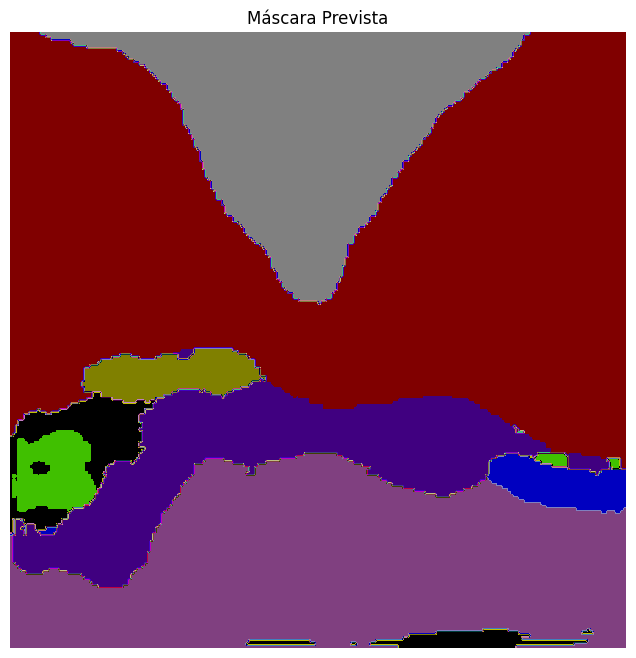



Selecione uma opção:
1. Executar o pipeline de treinamento
2. Executar o pipeline de teste
3. Sair


Digite o número da sua escolha: 3
Execução finalizada!


In [4]:
# @title
import ipywidgets as widgets
from IPython.display import display, HTML, Javascript
from sklearn import preprocessing
import numpy as np
import sys
import warnings
warnings.filterwarnings("ignore", message="Your PyDataset")
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings("ignore")
import tensorflow as tf
import os
import logging
# Define o nível de log da Tensorflow para 3 e ignora os demais níveis
logging.disable(logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0 (INFO), 1 (WARNING), 2 (ERROR), 3 (FATAL)

#####################
# MONTAGEM DO DRIVE #
#####################
from google.colab import drive
if not os.path.ismount('/content/drive'):
    print("Montando o Google Drive...")
    drive.mount('/content/drive')

###########################
# CARREGAMENTO DE MÓDULOS #
###########################

# Caminho dos módulos do projeto armazenados no Google Drive
caminho_modulos = '/content/drive/MyDrive/Colab Notebooks/VC/Segmentacao_Semantica/modulos'
from pydoc import importfile
# Importação de módulos Python
modulo_unet_treino = importfile(caminho_modulos+'/unet_treino.py')
modulo_unet_teste = importfile(caminho_modulos+'/unet_teste.py')

########################################################################
# CAMINHOS E VARIAVES GLOBAIS
########################################################################

caminho_base = '/content/drive/MyDrive/Colab Notebooks/VC/Segmentacao_Semantica'
caminho_todos_datasets = caminho_base + '/datasets/'
selected_dataset = 'CamVid'
caminho_imagens_treino = caminho_todos_datasets + selected_dataset + '/train/'
caminho_rotulos_treino = caminho_todos_datasets + selected_dataset + '/train_labels/'
caminho_imagens_val = caminho_todos_datasets + selected_dataset + '/val/'
caminho_rotulos_val = caminho_todos_datasets + selected_dataset + '/val_labels/'
caminho_imagens_teste = caminho_todos_datasets + selected_dataset + '/test/'
caminho_rotulos_teste = caminho_todos_datasets + selected_dataset + '/test_labels/'
caminho_mapeamento_classes = caminho_todos_datasets + selected_dataset + '/class_dict.csv'

caminho_log = caminho_base + '/log/logger.csv'
caminho_checkpoints = caminho_base + '/checkpoints/cp.weights.h5'
caminho_modelo_unet_treinado = caminho_base + '/modelos/my_unet.keras'
caminho_resultados = caminho_base + '/resultados/'
forma_img = (224,224,3)
metrica = 'accuracy'
num_epocas = 50
learning_rate = 0.001

########################################################################
# FUNÇÕES DE EXECUÇÃO DOS PIPELINES
########################################################################

def pipeline_treinamento():
    print(f'\n\n----- Iniciando Pipeline de Treinamento -----\n\n')
    ########################################################################
    # OBTEM AS IMAGENS DE TREINAMENTO E VALIDACAO
    ########################################################################

    mapeamento_classes, nomes_classes = modulo_unet_treino.carregar_mapeamento_classes(caminho_mapeamento_classes)

    # Carregando os datasets de treinamento e validação
    imagens_treino, rotulos_treino = modulo_unet_treino.carregar_dataset(
        caminho_imagens_treino,
        caminho_rotulos_treino,
        forma_img,
        mapeamento_classes
    )
    imagens_val, rotulos_val = modulo_unet_treino.carregar_dataset(
        caminho_imagens_val,  # Corrigido para o caminho de validação correto
        caminho_rotulos_val,  # Corrigido para o caminho de validação correto
        forma_img,
        mapeamento_classes
    )



    # Expande a dimensão para as máscaras, pois o U-Net espera uma
    # dimensão adicional para as classes
    rotulos_treino = np.expand_dims(rotulos_treino, axis=-1)
    rotulos_val = np.expand_dims(rotulos_val, axis=-1)

    # Calcula o número de classes
    num_classes = len(nomes_classes)


    ########################################################################
    # OBTEM E COMPILA O MODELO
    ########################################################################

    modelo_unet = modulo_unet_treino.obter_modelo_unet(forma_img, num_classes)
    modelo_compilado = modulo_unet_treino.compilar_modelo_unet(
        modelo_unet,
        metrica,
        learning_rate,
        num_classes
    )

    ########################################################################
    # OBTEM A LISTA DE CALLBACKS
    ########################################################################

    cp = modulo_unet_treino.obter_checkpoint_callback(caminho_checkpoints)
    log = modulo_unet_treino.obter_log_callback(caminho_log)
    lr = modulo_unet_treino.obter_reduce_lr_callback()
    es = modulo_unet_treino.obter_early_stop_callback()
    lista_callbacks = [cp, log, lr, es]

    ########################################################################
    # TREINA O MODELO
    ########################################################################

    modelo_treinado, historico = modulo_unet_treino.treinar_modelo_unet(
        modelo_compilado,
        imagens_treino, rotulos_treino,
        imagens_val, rotulos_val,
        num_epocas,
        caminho_checkpoints,
        lista_callbacks
    )

    ########################################################################
    # SALVA MODELO
    ########################################################################

    modulo_unet_treino.salvar_modelo(modelo_treinado, caminho_modelo_unet_treinado)

    ########################################################################
    # PLOTA E SALVA HISTÓRICO DO TREINAMENTO
    ########################################################################

    modulo_unet_treino.plot_historico(historico,metrica,caminho_resultados)


def pipeline_teste():
    print(f'\n\n----- Iniciando Pipeline de Teste -----\n\n')
    ########################################################################
    # OBTEM AS IMAGENS E OS ROTULOS DE TESTE
    ########################################################################

    mapeamento_classes, nomes_classes = modulo_unet_teste.carregar_mapeamento_classes(caminho_mapeamento_classes)

    # Carregando os datasets de teste
    imagens_teste, rotulos_teste = modulo_unet_teste.carregar_dataset(
        caminho_imagens_teste,
        caminho_rotulos_teste,
        forma_img,
        mapeamento_classes
    )

    # Expande a dimensão para as máscaras, se necessário
    rotulos_teste = np.expand_dims(rotulos_teste, axis=-1)

    ########################################################################
    # CARREGA O MODELO TREINADO A PARTIR DE UM ARQUIVO
    ########################################################################

    modelo_unet = modulo_unet_teste.carregar_modelo_unet_treinado(caminho_modelo_unet_treinado)

    ########################################################################
    # TESTA O MODELO
    ########################################################################

    # Avaliação do modelo utilizando o dataset de teste
    resultados = modelo_unet.evaluate(imagens_teste, rotulos_teste, verbose=1)
    # Realiza previsões no dataset de teste
    previsoes = modelo_unet.predict(imagens_teste)
    modulo_unet_teste.visualizar_previsao(previsoes[47], mapeamento_classes, titulo=f"Máscara Prevista")

    print(f'\n\n----- Resultados da Avaliação -----\n\n')
    print(f'Resultados: {resultados}')


########################################################################
# MENU PARA ESCOLHA DOS PIPELINES
 ########################################################################

def menu():
    while True:
        print("\n")
        print("Selecione uma opção:")
        print("1. Executar o pipeline de treinamento")
        print("2. Executar o pipeline de teste")
        print("3. Sair")
        print("\n")

        escolha = input("Digite o número da sua escolha: ")

        if escolha == '1':
            pipeline_treinamento()
        elif escolha == '2':
            pipeline_teste()
        elif escolha == '3':
            print("Execução finalizada!")
            break
        else:
            print("Escolha inválida. Por favor, selecione uma opção válida.")

# Chamada do menu para que o usuário faça a escolha
menu()


################ FIM DO SCRIPT ########################
